# ARIN 5204:  Homework 2

**Instructions:** Complete all code blanks marked with **TODO** comments while do not modify any other codes.

## 1. Sarsa (On-Policy) vs Q-Learning (Off-Policy)

### Cliff Walking

We'll use a classic grid-world environment called "Cliff Walk."


- **Environment**: A 4x12 grid
- **State**: The agent's position (row, col)
- **Start Point**: `(3, 0)` (lower left corner)
- **End**: `(3, 11)` (lower right corner)
- **Action**: 4 (up, down, left, right)
- **Reward**:
  - Each step: `-1`
  - Falling off a cliff (from `(3, 1)` to `(3, 10)` in row 3): `-100`, resetting to the starting point.
  - Reaching the end: `0` (end of episode)

## Import the package

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, List
import random
from collections import deque
import time

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("colorblind")

## Define the environment class

In [2]:
class CliffWalkingEnv:
    def __init__(self):
        self.rows = 4
        self.cols = 12
        self.start_pos = (3, 0)
        self.goal_pos = (3, 11)
        self.cliff = [(3, i) for i in range(1, 11)]
        self.state = self.start_pos
        self.actions = [0, 1, 2, 3] # 0:up, 1:down, 2:left, 3:right
        self.nS = self.rows * self.cols
        self.nA = len(self.actions)

    def reset(self) -> Tuple[int, int]:
        self.state = self.start_pos
        return self.state

    def _to_state_index(self, state: Tuple[int, int]) -> int:
        return state[0] * self.cols + state[1]

    def _to_state_tuple(self, index: int) -> Tuple[int, int]:
        return (index // self.cols, index % self.cols)

    def step(self, action: int) -> Tuple[Tuple[int, int], float, bool]:
        r, c = self.state

        if action == 0: # up
            r = max(0, r - 1)
        elif action == 1: # down
            r = min(self.rows - 1, r + 1)
        elif action == 2: # left
            c = max(0, c - 1)
        elif action == 3: # right
            c = min(self.cols - 1, c + 1)

        next_state = (r, c)
        reward = -1.0
        done = False

        if next_state == self.goal_pos:
            reward = 0.0
            done = True
        elif next_state in self.cliff:
            reward = -100.0
            next_state = self.start_pos

        self.state = next_state
        return next_state, reward, done

## Define the agent

### Algorithm

1. **Sarsa (On-Policy)**: Learns the value of the policy it is currently following (ε-greedy).

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma Q(s', a') - Q(s, a) \right)$$



It is updated using the next state $s'$ and the next action $a'$ *actually* chosen in that state.



2. **Q-Learning (Off-Policy)**: Learns the value of the *optimal policy* (greedy), regardless of the current policy it is following.

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right)$$


It is updated using the next state $s'$ and the action $a'$ that *could* produce the maximum Q value in that state.

In [3]:
class TDAgent:
    """A base class compatible with both Sarsa and Q-Learning"""
    def __init__(self, env: CliffWalkingEnv, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = np.zeros((env.nS, env.nA))

    def _state_to_idx(self, state: Tuple[int, int]) -> int:
        return self.env._to_state_index(state)

    def select_action(self, state: Tuple[int, int]) -> int:
        # epsilon-greedy
        state_idx = self._state_to_idx(state)
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.env.nA)
        else:
            best_actions = np.flatnonzero(self.q_table[state_idx] == np.max(self.q_table[state_idx]))
            return np.random.choice(best_actions)

class SarsaAgent(TDAgent):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def update(self, state, action, reward, next_state, next_action):
        # TODO 1
        # |‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾|
        state_idx = self._state_to_idx(state)
        next_state_idx = self._state_to_idx(next_state)
        # Sarsa (On-Policy):
        self.q_table[state_idx, action] += self.alpha * (
            reward + self.gamma * self.q_table[next_state_idx, next_action]
            - self.q_table[state_idx, action]
        )
        # |_________________________________________________|


class QLearningAgent(TDAgent):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def update(self, state, action, reward, next_state):
        # TODO 2
        # |‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾|
        state_idx = self._state_to_idx(state)
        next_state_idx = self._state_to_idx(next_state)
        # Q-Learning (Off-Policy):
        self.q_table[state_idx, action] += self.alpha * (
            reward + self.gamma * np.max(self.q_table[next_state_idx])
            - self.q_table[state_idx, action]
        )
        # |_________________________________________________|

## Training process

In [4]:
def run_experiment_sarsa_q(env: CliffWalkingEnv, num_runs=50, num_episodes=500, alpha=0.1, epsilon=0.1):

    all_rewards = {'sarsa': np.zeros((num_runs, num_episodes)),
                   'q_learning': np.zeros((num_runs, num_episodes))}

    final_sarsa_agent = None
    final_q_agent = None

    for run in range(num_runs):

        sarsa_agent = SarsaAgent(env, alpha=alpha, epsilon=epsilon)
        q_agent = QLearningAgent(env, alpha=alpha, epsilon=epsilon)

        # Sarsa
        for ep in range(num_episodes):
            state = env.reset()
            action = sarsa_agent.select_action(state)
            done = False
            episode_reward = 0

            while not done:
                # TODO 3: Implement the Sarsa (s, a, r, s', a') loop
                # |‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾|
                next_state, reward, done = env.step(action)
                next_action = sarsa_agent.select_action(next_state)
                sarsa_agent.update(state, action, reward, next_state, next_action)
                episode_reward += reward
                state = next_state
                action = next_action
                # |_________________________________________________|
            all_rewards['sarsa'][run, ep] = episode_reward

        # Q-Learning
        for ep in range(num_episodes):
            state = env.reset()
            done = False
            episode_reward = 0

            while not done:
                # TODO 4: Implement the Q-Learning (s, a, r, s') loop
                # |‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾|
                action = q_agent.select_action(state)
                next_state, reward, done = env.step(action)
                q_agent.update(state, action, reward, next_state)
                episode_reward += reward
                state = next_state
                # |_________________________________________________|
            all_rewards['q_learning'][run, ep] = episode_reward

        # Save the agents from the last run
        if run == num_runs - 1:
            final_sarsa_agent = sarsa_agent
            final_q_agent = q_agent

    return all_rewards, final_sarsa_agent, final_q_agent

## Visualization function

In [5]:
def plot_sarsa_q(results: Dict):

    def smooth(data, window=10):
        if data.size < window:
            return data
        return np.convolve(data, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(12, 6))

    sarsa_mean = np.mean(results['sarsa'], axis=0)
    sarsa_std = np.std(results['sarsa'], axis=0)
    q_mean = np.mean(results['q_learning'], axis=0)
    q_std = np.std(results['q_learning'], axis=0)

    window_size = 20
    sarsa_smooth = smooth(sarsa_mean, window_size)
    q_smooth = smooth(q_mean, window_size)

    x = np.arange(len(sarsa_smooth))

    plt.plot(x, sarsa_smooth, label='Sarsa (On-Policy)', color='blue')
    plt.plot(x, q_smooth, label='Q-Learning (Off-Policy)', color='red')

    plt.xlabel('Episodes')
    plt.ylabel('Averaged overall reward by Episodes')
    plt.title('Sarsa vs. Q-Learning (cliff-walking)')
    plt.legend()
    plt.ylim(-150, 0)
    plt.show()

def plot_policy(agent: TDAgent, env: CliffWalkingEnv, title: str):
    """Visualizes the greedy policy (solution) learned by the agent."""

    # 0:up, 1:down, 2:left, 3:right
    policy_symbols = ['↑', '↓', '←', '→']

    policy_grid = np.full((env.rows, env.cols), " ", dtype=str)

    # -1: cliff, 0: normal, 0.5: start, 1: goal
    background = np.zeros((env.rows, env.cols))

    for r in range(env.rows):
        for c in range(env.cols):
            state = (r, c)
            state_idx = env._to_state_index(state)

            # Get the best action for the current state
            best_action = np.argmax(agent.q_table[state_idx])
            policy_grid[r, c] = policy_symbols[best_action]

            # Set background colors for special states
            if state == env.goal_pos:
                policy_grid[r, c] = 'G' # Goal
                background[r, c] = 1
            elif state in env.cliff:
                policy_grid[r, c] = ''   # No action on cliff
                background[r, c] = -1
            elif state == env.start_pos:
                background[r, c] = 0.5

    plt.figure(figsize=(10, 4))

    # Colormap: black (cliff), white (normal), yellow (start), green (goal)
    cmap = plt.cm.colors.ListedColormap(['black', 'white', 'yellow', 'green'])
    bounds = [-1.5, -0.5, 0.25, 0.75, 1.5]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

    plt.imshow(background, cmap=cmap, norm=norm)

    for r in range(env.rows):
        for c in range(env.cols):
            text_color = 'white' if (r, c) in env.cliff else 'black'
            if (r,c) == env.goal_pos:
                text_color = 'black'
            plt.text(c, r, policy_grid[r, c],
                     ha='center', va='center', color=text_color, fontsize=14)

    plt.title(title, fontsize=16)
    plt.xticks(np.arange(env.cols))
    plt.yticks(np.arange(env.rows))
    plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
    plt.gca().set_xticks(np.arange(-.5, env.cols, 1), minor=True)
    plt.gca().set_yticks(np.arange(-.5, env.rows, 1), minor=True)
    plt.grid(which='minor', color='black', linestyle='-', linewidth=1)
    plt.show()

## Run Experiment and Visualize Results


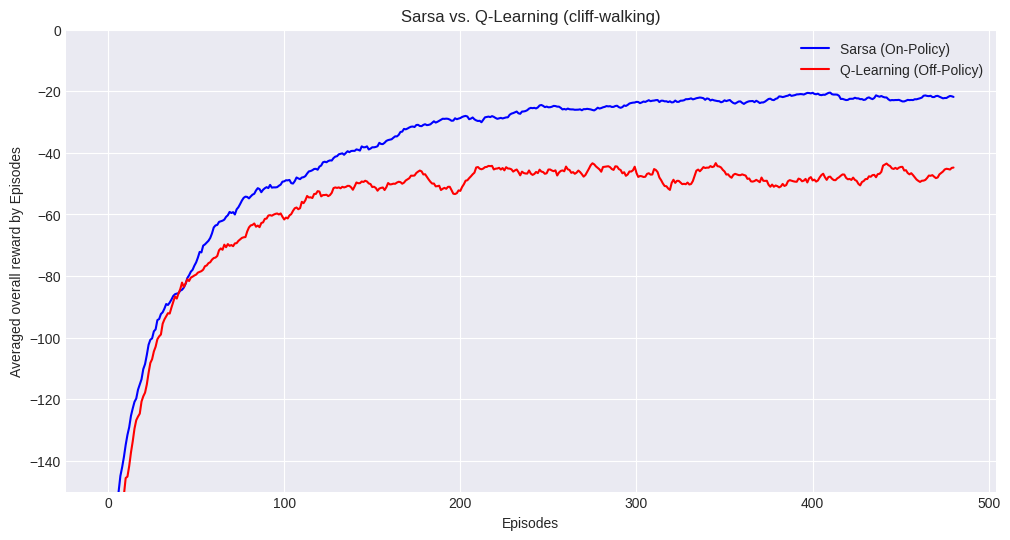

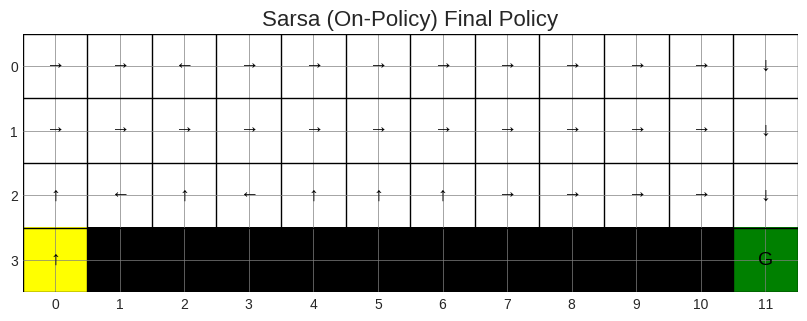

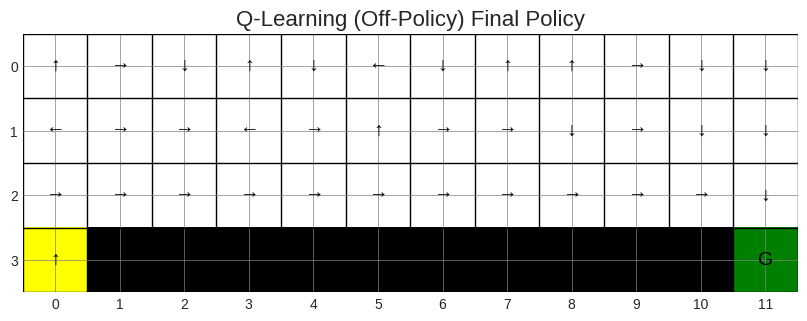

In [6]:
env_cliff = CliffWalkingEnv()

# Run the experiment
sarsa_q_results, final_sarsa_agent, final_q_agent = run_experiment_sarsa_q(
    env_cliff, num_runs=50, num_episodes=500, alpha=0.1, epsilon=0.1
)

# 1. Plot the reward comparison
plot_sarsa_q(sarsa_q_results)

# 2. Plot the final learned policies (solutions)
plot_policy(final_sarsa_agent, env_cliff, title="Sarsa (On-Policy) Final Policy")
plot_policy(final_q_agent, env_cliff, title="Q-Learning (Off-Policy) Final Policy")

## 2. DQN vs Double DQN

### FrozenLake

We'll use the "FrozenLake-v1" environment from Gymnasium.


- **Environment**: A 4x4 grid. The agent must navigate from a start to a goal state.
- **World**:
  - `S`: Start (safe)
  - `F`: Frozen (safe)
  - `H`: Hole (ends episode)
  - `G`: Goal (ends episode, reward +1)
- **State**: The agent's position (an integer from 0 to 15).
- **Start Point**: State 0 `(0, 0)` (top left corner)
- **Goal**: State 15 `(3, 3)` (bottom right corner)
- **Action**: 4 (0: left, 1: down, 2: right, 3: up)
- **Reward**:
  - Reaching the goal: `+1`
  - All other steps (including falling in a hole): `0`



## Import the package

In [10]:
!pip install gymnasium
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, List, NamedTuple
import random
from collections import deque, namedtuple
import time
import copy

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = "cpu"
# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("colorblind")

# Define the transition tuple
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

## Define Q-Network and replay buffer

In [11]:
class QNetwork(nn.Module):
    def __init__(self, nS: int, nA: int, hidden_dim: int = 64):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(nS, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, nA)

    def forward(self, state_one_hot: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(state_one_hot))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class ReplayBuffer:
    def __init__(self, capacity: int):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size: int) -> List[Transition]:
        return random.sample(self.memory, batch_size)

    def __len__(self) -> int:
        return len(self.memory)

## Define the agent

### Algorithm

1. **DQN (Deep Q-Networks)**: Uses a target network $\theta'$ to stabilize training. The target $Y_t$ is calculated using the action that maximizes the Q-value from the **target network**.

$$Y_t^{DQN} = r + \gamma \max_{a'} Q(s', a'; \theta'_t)$$

This can lead to overestimation because the same network is used to both *select* and *evaluate* the best next action.

2. **Double DQN**: Decouples action selection from action evaluation. The **policy network** $\theta_t$ selects the best action $a^*$, and the **target network** $\theta'_t$ evaluates its Q-value.

$$a^* = \arg\max_{a'} Q(s', a'; \theta_t)$$
$$Y_t^{DoubleDQN} = r + \gamma Q(s', a^*; \theta'_t)$$

This helps reduce the overestimation bias of standard DQN.

In [12]:
class BaseDQNAgent:
    def __init__(self, env, gamma=0.99, buffer_size=10000, lr=1e-3):
        self.env = env
        self.nS = env.observation_space.n
        self.nA = env.action_space.n
        self.gamma = gamma
        self.device = device

        self.policy_net = QNetwork(self.nS, self.nA).to(self.device)
        self.target_net = QNetwork(self.nS, self.nA).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay_buffer = ReplayBuffer(buffer_size)

    def _one_hot(self, states: Tuple[int, ...]) -> torch.Tensor:
        if not isinstance(states, torch.Tensor):
            states_tensor = torch.tensor(states, device=self.device, dtype=torch.long)
        else:
            states_tensor = states.to(self.device).long()

        return F.one_hot(states_tensor, num_classes=self.nS).float()

    def select_action(self, state: int, epsilon: float) -> int:
        # epsilon-greedy
        if np.random.rand() < epsilon:
            return np.random.choice(self.nA)
        else:
            with torch.no_grad():
                state_oh = self._one_hot((state,)).to(self.device)
                q_values = self.policy_net(state_oh)
                return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def update_target_net(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())


class DQNAgent(BaseDQNAgent):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def update(self, batch_size: int):
        if len(self.replay_buffer) < batch_size:
            return

        transitions = self.replay_buffer.sample(batch_size)
        batch = Transition(*zip(*transitions))

        state_batch = self._one_hot(batch.state)
        action_batch = torch.tensor(batch.action, device=self.device).unsqueeze(1)
        reward_batch = torch.tensor(batch.reward, device=self.device).float()
        next_state_batch = self._one_hot(batch.next_state)
        done_batch = torch.tensor(batch.done, device=self.device).float()

        current_q = self.policy_net(state_batch).gather(1, action_batch)


        with torch.no_grad():
          # TODO 5: Compute the DQN target Y_t
          # |‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾|
            next_q = self.target_net(next_state_batch).max(1)[0]
            target_q = reward_batch + (1 - done_batch) * self.gamma * next_q
          # |_________________________________________________|

        loss = F.mse_loss(current_q, target_q.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


class DoubleDQNAgent(BaseDQNAgent):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def update(self, batch_size: int):
        if len(self.replay_buffer) < batch_size:
            return

        transitions = self.replay_buffer.sample(batch_size)
        batch = Transition(*zip(*transitions))

        state_batch = self._one_hot(batch.state)
        action_batch = torch.tensor(batch.action, device=self.device).unsqueeze(1)
        reward_batch = torch.tensor(batch.reward, device=self.device).float()
        next_state_batch = self._one_hot(batch.next_state)
        done_batch = torch.tensor(batch.done, device=self.device).float()

        current_q = self.policy_net(state_batch).gather(1, action_batch)


        with torch.no_grad():
            # TODO 6: Compute the Double DQN target Y_t
            # |‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾|
            best_actions = self.policy_net(next_state_batch).max(1)[1].unsqueeze(1)
            next_q = self.target_net(next_state_batch).gather(1, best_actions).squeeze()
            target_q = reward_batch + (1 - done_batch) * self.gamma * next_q
            # |_________________________________________________|

        loss = F.mse_loss(current_q, target_q.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

## Training process

In [13]:
def run_experiment_dqn(env: gym.Env, num_runs=20, num_episodes=2000,
                       buffer_size=10000, lr=1e-3, gamma=0.99, batch_size=64,
                       target_update_freq=10,
                       epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):

    all_rewards = {'dqn': np.zeros((num_runs, num_episodes)),
                   'double_dqn': np.zeros((num_runs, num_episodes))}

    final_dqn_agent = None
    final_ddqn_agent = None

    for run in range(num_runs):
        print(f"Run {run + 1}/{num_runs}")
        dqn_agent = DQNAgent(env, gamma=gamma, buffer_size=buffer_size, lr=lr)
        ddqn_agent = DoubleDQNAgent(env, gamma=gamma, buffer_size=buffer_size, lr=lr)

        agents = {'dqn': dqn_agent, 'double_dqn': ddqn_agent}

        for agent_name, agent in agents.items():
            epsilon = epsilon_start
            for ep in range(num_episodes):
                state, _ = env.reset()
                done = False
                truncated = False
                episode_reward = 0

                while not done and not truncated:
                    # TODO 7: Implement the DQN or Double DQN (s, a, r, s') loop
                    # |‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾|
                    action = agent.select_action(state, epsilon)
                    next_state, reward, done, truncated, _ = env.step(action)
                    agent.store_transition(state, action, reward, next_state, done)
                    agent.update(batch_size)
                    episode_reward += reward
                    state = next_state

                    # |_________________________________________________|

                epsilon = max(epsilon_end, epsilon * epsilon_decay)

                if ep % target_update_freq == 0:
                    agent.update_target_net()

                all_rewards[agent_name][run, ep] = episode_reward

        if run == num_runs - 1:
            final_dqn_agent = dqn_agent
            final_ddqn_agent = ddqn_agent

    return all_rewards, final_dqn_agent, final_ddqn_agent

## Visualization function

In [14]:
def plot_dqn_ddqn(results: Dict):

    def smooth(data, window=50):
        if data.size < window:
            return data
        return np.convolve(data, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(12, 6))

    dqn_mean = np.mean(results['dqn'], axis=0)
    ddqn_mean = np.mean(results['double_dqn'], axis=0)

    window_size = 50
    dqn_smooth = smooth(dqn_mean, window_size)
    ddqn_smooth = smooth(ddqn_mean, window_size)

    x = np.arange(len(dqn_smooth))

    plt.plot(x, dqn_smooth, label='DQN', color='blue')
    plt.plot(x, ddqn_smooth, label='Double DQN', color='red')

    plt.xlabel('Episodes')
    plt.ylabel(f'Averaged Success Rate (Smoothed, window={window_size})')
    plt.title('DQN vs. Double DQN (FrozenLake-v1)')
    plt.legend()
    plt.ylim(0, 1.0)
    plt.show()

def plot_policy_frozenlake(agent: BaseDQNAgent, env_desc: np.ndarray, title: str):

    # 0:left, 1:down, 2:right, 3:up
    policy_symbols = ['←', '↓', '→', '↑']
    rows, cols = env_desc.shape

    policy_grid = np.full((rows, cols), " ", dtype=str)
    background = np.zeros((rows, cols))

    for r in range(rows):
        for c in range(cols):
            state_idx = r * cols + c

            # Get the best action for the current state
            best_action = agent.select_action(state_idx, epsilon=0.0) # Greedy action
            policy_grid[r, c] = policy_symbols[best_action]

            # Set background colors for special states
            tile = env_desc[r, c]
            if tile == b'G':
                policy_grid[r, c] = 'G' # Goal
                background[r, c] = 1
            elif tile == b'H':
                policy_grid[r, c] = ''   # No action on hole
                background[r, c] = -1
            elif tile == b'S':
                background[r, c] = 0.5
            elif tile == b'F':
                background[r, c] = 0

    plt.figure(figsize=(6, 6))

    # Colormap: black (Hole), white (Frozen), lightblue (Start), lightgreen (Goal)
    cmap = plt.cm.colors.ListedColormap(['black', 'white', 'lightblue', 'lightgreen'])
    bounds = [-1.5, -0.5, 0.25, 0.75, 1.5]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

    plt.imshow(background, cmap=cmap, norm=norm)

    for r in range(rows):
        for c in range(cols):
            text_color = 'white' if env_desc[r, c] == b'H' else 'black'
            if env_desc[r, c] == b'G':
                text_color = 'black'
            plt.text(c, r, policy_grid[r, c],
                     ha='center', va='center', color=text_color, fontsize=20)

    plt.title(title, fontsize=16)
    plt.xticks(np.arange(cols))
    plt.yticks(np.arange(rows))
    plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
    plt.gca().set_xticks(np.arange(-.5, cols, 1), minor=True)
    plt.gca().set_yticks(np.arange(-.5, rows, 1), minor=True)
    plt.grid(which='minor', color='black', linestyle='-', linewidth=1)
    plt.show()

## Run Experiment and Visualize Results


Run 1/5
Run 2/5
Run 3/5
Run 4/5
Run 5/5


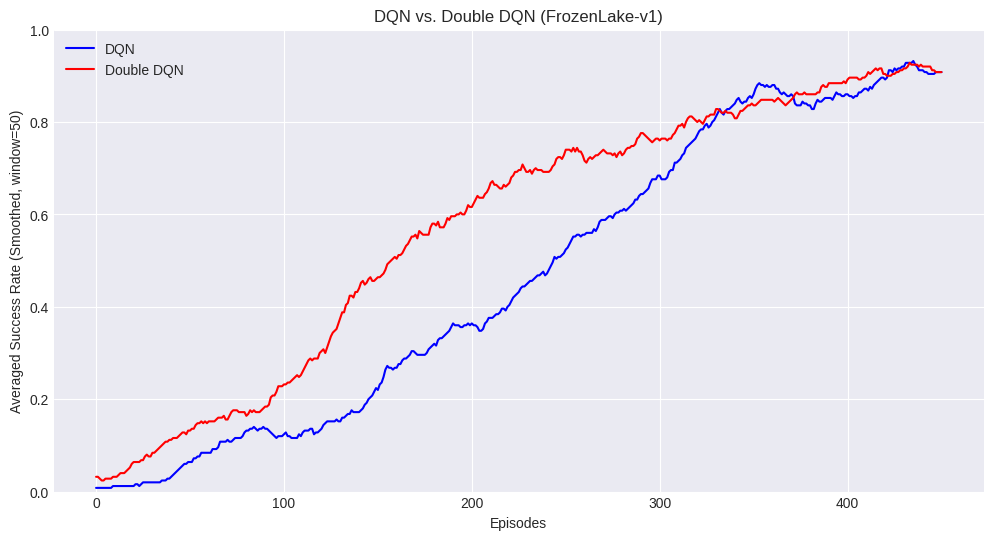

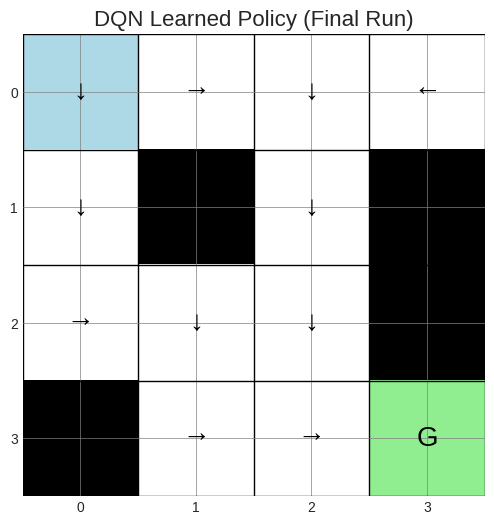

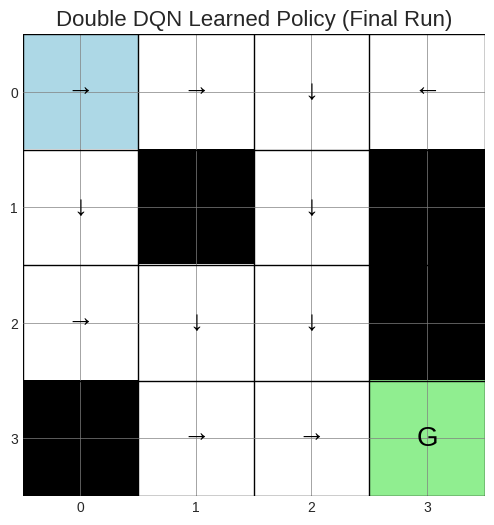

In [15]:

env = gym.make("FrozenLake-v1", is_slippery=False)

# Hyperparameters
NUM_RUNS = 5         # Number of independent runs to average over
NUM_EPISODES = 500 # Number of episodes per run
BUFFER_SIZE = 10000   # Replay buffer capacity
LEARNING_RATE = 1e-3  # Learning rate for Adam optimizer
GAMMA = 0.99          # Discount factor
BATCH_SIZE = 64       # Batch size for sampling from replay buffer
TARGET_UPDATE_FREQ = 10 # Episodes between target network updates
EPSILON_START = 1.0   # Initial epsilon
EPSILON_END = 0.01    # Final epsilon
EPSILON_DECAY = 0.995 # Multiplicative decay factor for epsilon

# Run the experiment
results, final_dqn, final_ddqn = run_experiment_dqn(
    env,
    num_runs=NUM_RUNS,
    num_episodes=NUM_EPISODES,
    buffer_size=BUFFER_SIZE,
    lr=LEARNING_RATE,
    gamma=GAMMA,
    batch_size=BATCH_SIZE,
    target_update_freq=TARGET_UPDATE_FREQ,
    epsilon_start=EPSILON_START,
    epsilon_end=EPSILON_END,
    epsilon_decay=EPSILON_DECAY
)

# Plot the results
plot_dqn_ddqn(results)

# Plot the learned policies
plot_policy_frozenlake(final_dqn, env.unwrapped.desc, "DQN Learned Policy (Final Run)")
plot_policy_frozenlake(final_ddqn, env.unwrapped.desc, "Double DQN Learned Policy (Final Run)")

env.close()